<a href="https://www.kaggle.com/code/lalit7881/petsmart-retail-products-dataset-eda?scriptVersionId=310823633" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/upcoderr/petsmart-retail-products-dataset/pet_supplies.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/upcoderr/petsmart-retail-products-dataset/pet_supplies.csv")

In [3]:
df.head()

,title,averageStar,quantity,tradeAmount,wishedCount
0,Mesh Litter Spatula Poop Remover Pet Cleaning ...,0.0,9993,5 sold,0
1,Rechargeable Mini Pet Communication Small Reco...,5.0,1986,28 sold,64
2,Dog Cooling Bed Mat Summer Puppy Cushion Soft ...,4.5,529,20 sold,38
3,Automatic Pet Feeder with Active RFID Technolo...,0.0,10,0 sold,1
4,Replace Plush Cat Toy Accessories Worms Replac...,4.9,102222,"1,000+ sold",418


In [4]:
df.tail()

,title,averageStar,quantity,tradeAmount,wishedCount
1993,Dog Birthday Party Decoration Set Pet Triangle...,4.8,41,142 sold,134
1994,PuppyToothbrush Cats Toothbrush- Pet Toothbrus...,5.0,10,24 sold,14
1995,Dog Toy Dogs Accessories Pet Toys Plush Toys f...,4.8,1000,135 sold,614
1996,Pet Dog Cat Car Seat Belt For Accessories Good...,5.0,598,34 sold,14
1997,350ml/550ml Portable Dog Water Bottle Bowl Out...,4.9,99897,92 sold,87


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1998 entries, 0 to 1997
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        1998 non-null   object 
 1   averageStar  1998 non-null   float64
 2   quantity     1998 non-null   int64  
 3   tradeAmount  1998 non-null   object 
 4   wishedCount  1998 non-null   int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 78.2+ KB


In [6]:
df.describe()

,averageStar,quantity,wishedCount
count,1998.000000,1.998000e+03,1998.000000
mean,4.159760,1.504057e+04,879.268268
std,1.544289,3.602017e+05,3219.786346
min,0.000000,0.000000e+00,0.000000
25%,4.500000,4.600000e+01,21.000000
50%,4.700000,1.765000e+02,95.500000
75%,4.900000,1.308000e+03,415.750000
max,5.000000,1.599864e+07,45939.000000


In [7]:
df.isnull().sum()

title          0
averageStar    0
quantity       0
tradeAmount    0
wishedCount    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df.dtypes

title           object
averageStar    float64
quantity         int64
tradeAmount     object
wishedCount      int64
dtype: object

In [10]:
df.shape

(1998, 5)

In [11]:
df.columns

Index(['title', 'averageStar', 'quantity', 'tradeAmount', 'wishedCount'], dtype='object')

In [12]:
df.nunique()

title          1826
averageStar      25
quantity        993
tradeAmount     396
wishedCount     783
dtype: int64

## EDA

In [13]:
# Remove text like "sold", commas, etc.

df['quantity'] = df['quantity'].astype(str).str.replace(r'[^0-9.]', '', regex=True)
df['tradeAmount'] = df['tradeAmount'].astype(str).str.replace(r'[^0-9.]', '', regex=True)
df['wishedCount'] = df['wishedCount'].astype(str).str.replace(r'[^0-9.]', '', regex=True)

# Convert to numeric
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
df['tradeAmount'] = pd.to_numeric(df['tradeAmount'], errors='coerce')
df['wishedCount'] = pd.to_numeric(df['wishedCount'], errors='coerce')

                                               title  averageStar  quantity  \
0  Mesh Litter Spatula Poop Remover Pet Cleaning ...          0.0      9993   
1  Rechargeable Mini Pet Communication Small Reco...          5.0      1986   
2  Dog Cooling Bed Mat Summer Puppy Cushion Soft ...          4.5       529   
3  Automatic Pet Feeder with Active RFID Technolo...          0.0        10   
4  Replace Plush Cat Toy Accessories Worms Replac...          4.9    102222   

   tradeAmount  wishedCount  
0          5.0            0  
1         28.0           64  
2         20.0           38  
3          0.0            1  
4       1000.0          418  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1998 entries, 0 to 1997
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        1998 non-null   object 
 1   averageStar  1998 non-null   float64
 2   quantity     1998 non-null   int64  
 3   tradeAmount  1998 non-nu

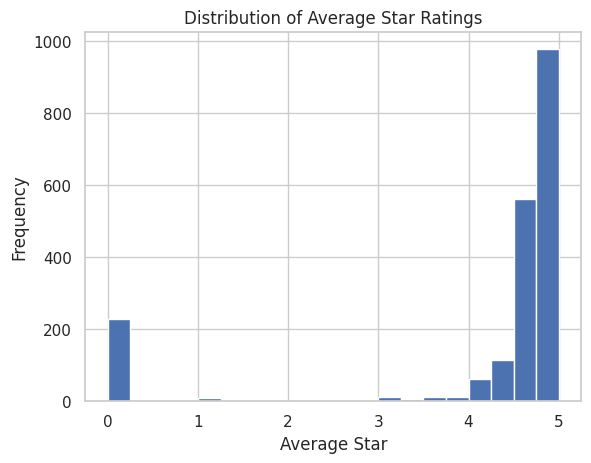

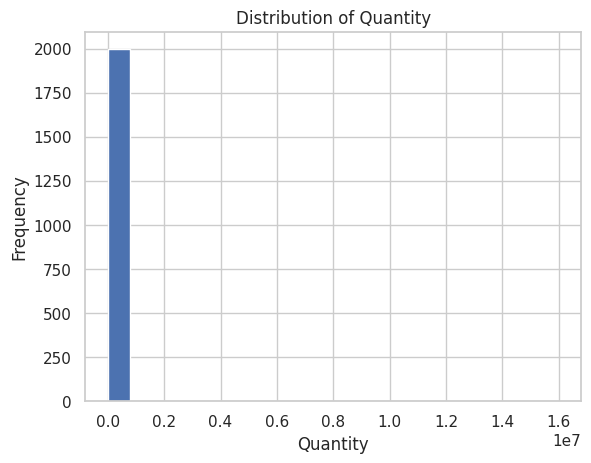

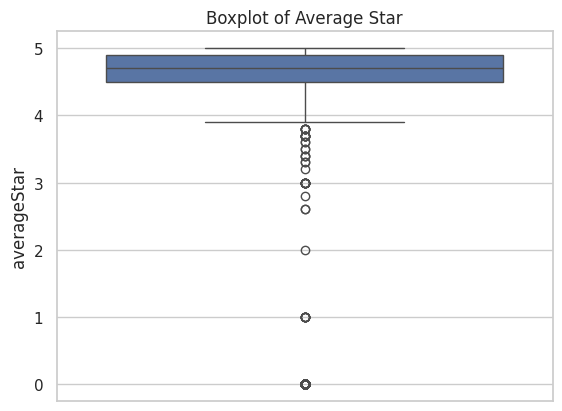

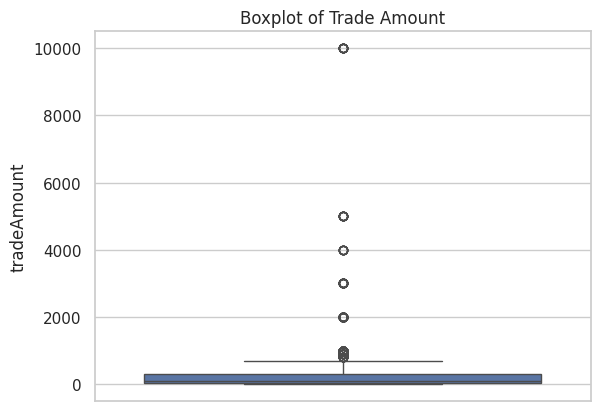

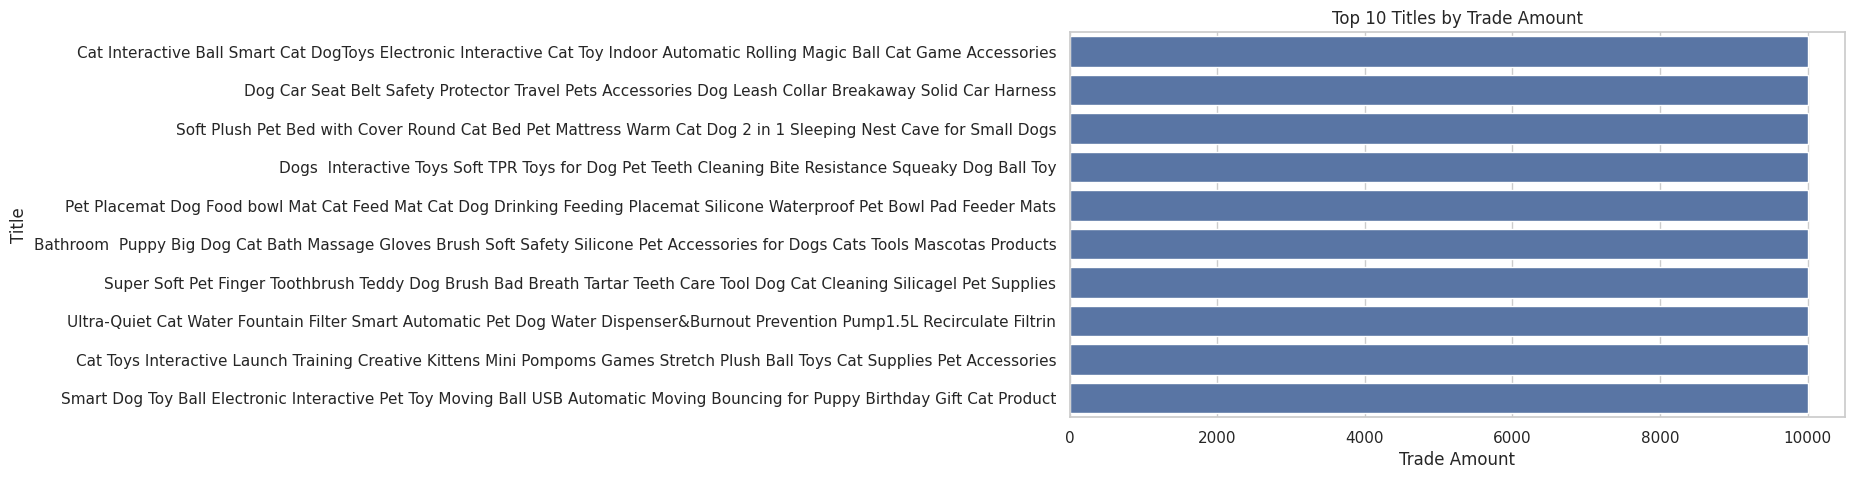

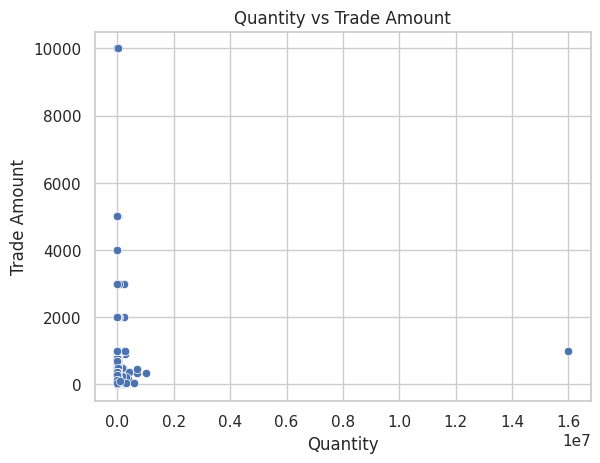

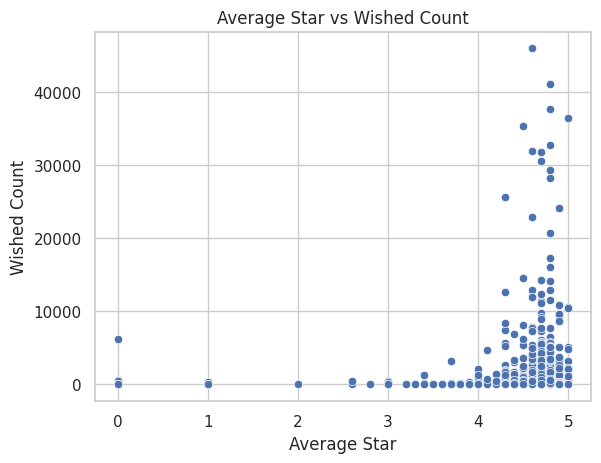

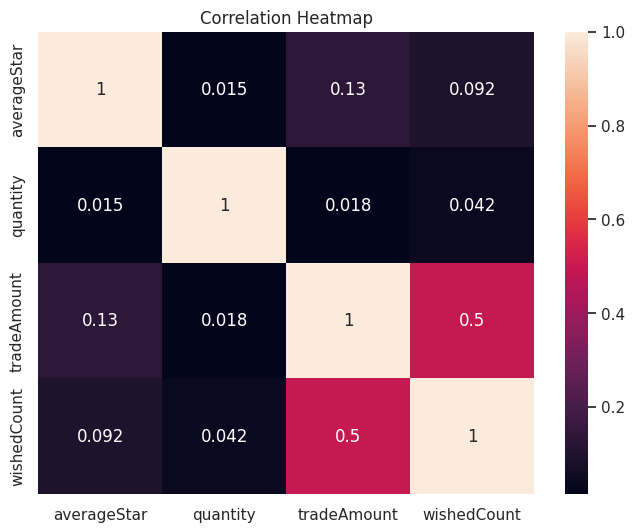

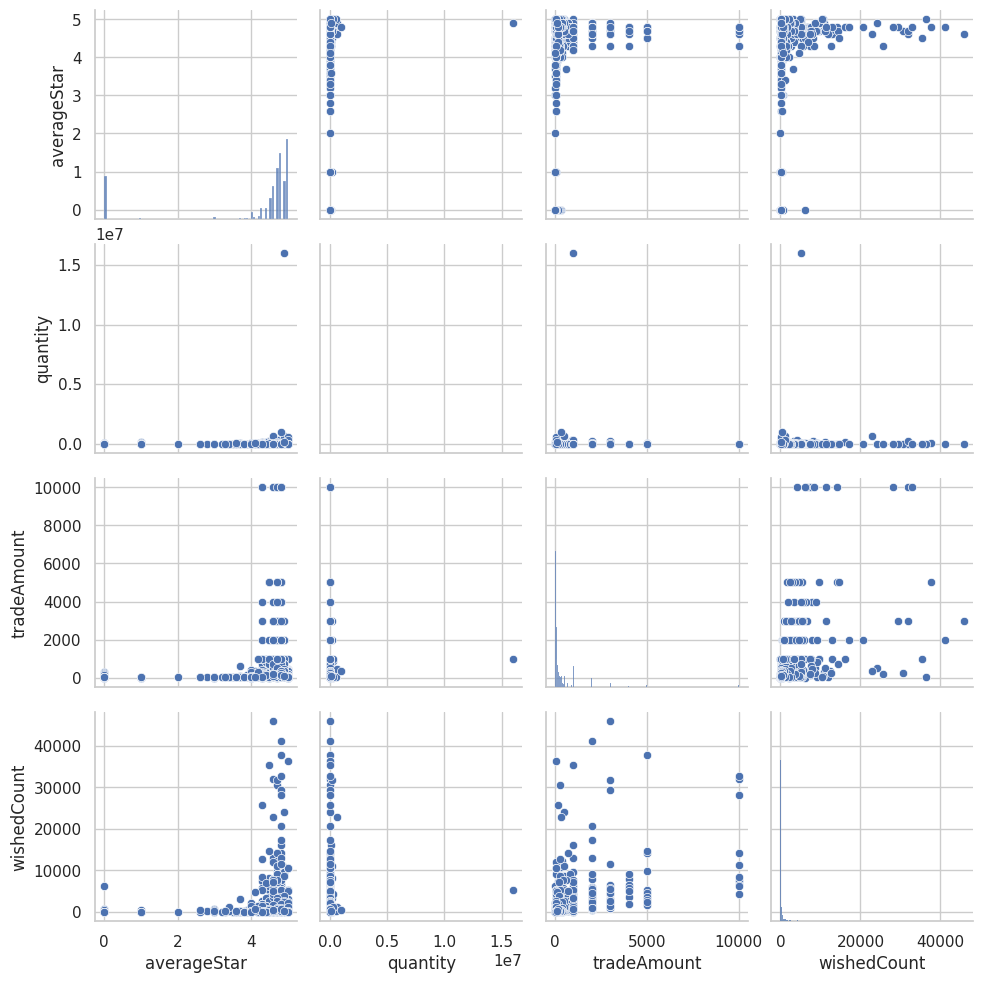

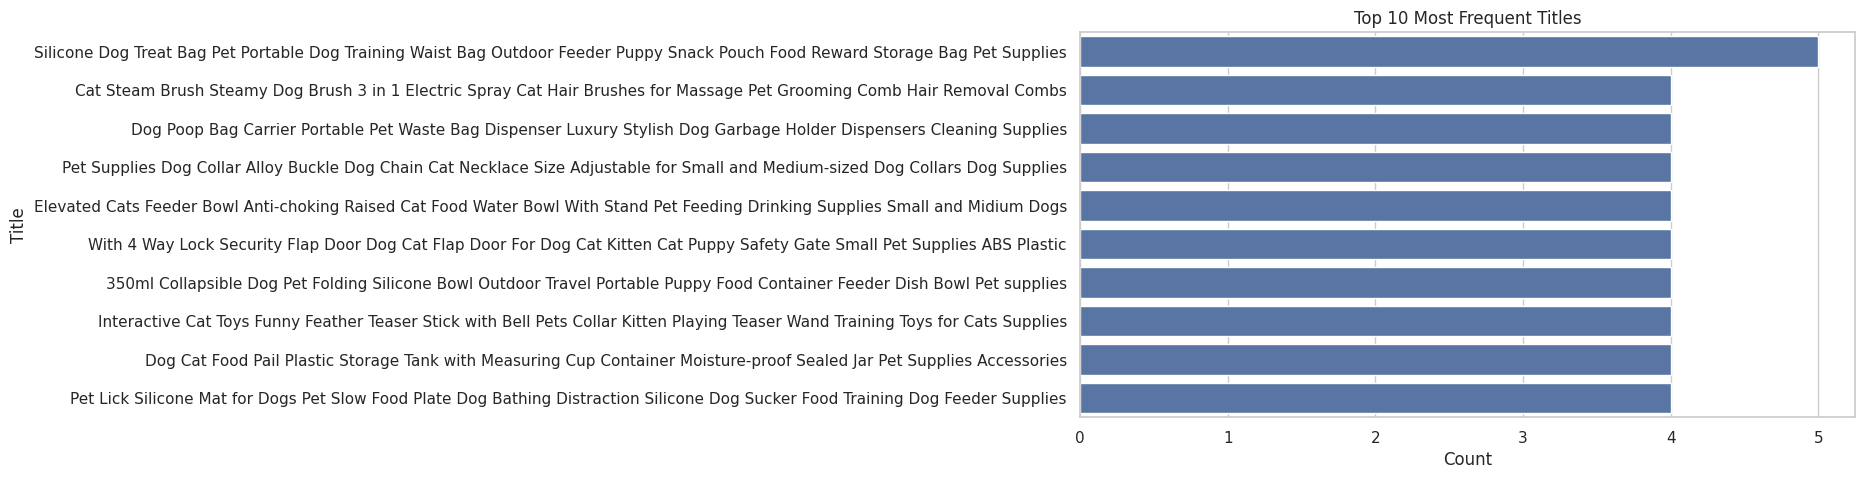

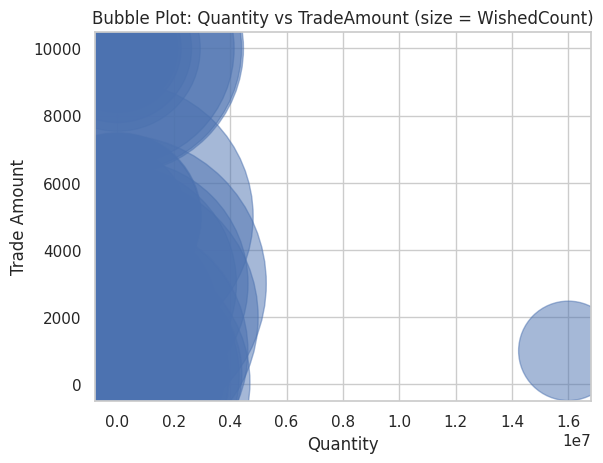

In [14]:

# Preview
print(df.head())

# Set style
sns.set(style="whitegrid")

# ================================
# 2. Basic Info
# ================================
print(df.info())
print(df.describe())

# ================================
# 3. Histogram (Distribution)
# ================================
plt.figure()
df['averageStar'].hist(bins=20)
plt.title("Distribution of Average Star Ratings")
plt.xlabel("Average Star")
plt.ylabel("Frequency")
plt.show()

plt.figure()
df['quantity'].hist(bins=20)
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

# ================================
# 4. Boxplots (Outlier Detection)
# ================================
plt.figure()
sns.boxplot(y=df['averageStar'])
plt.title("Boxplot of Average Star")
plt.show()

plt.figure()
sns.boxplot(y=df['tradeAmount'])
plt.title("Boxplot of Trade Amount")
plt.show()

# ================================
# 5. Bar Plot (Top Titles by Trade Amount)
# ================================
top_titles = df.sort_values(by='tradeAmount', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x='tradeAmount', y='title', data=top_titles)
plt.title("Top 10 Titles by Trade Amount")
plt.xlabel("Trade Amount")
plt.ylabel("Title")
plt.show()

# ================================
# 6. Scatter Plot (Relationships)
# ================================
plt.figure()
sns.scatterplot(x='quantity', y='tradeAmount', data=df)
plt.title("Quantity vs Trade Amount")
plt.xlabel("Quantity")
plt.ylabel("Trade Amount")
plt.show()

plt.figure()
sns.scatterplot(x='averageStar', y='wishedCount', data=df)
plt.title("Average Star vs Wished Count")
plt.xlabel("Average Star")
plt.ylabel("Wished Count")
plt.show()

# ================================
# 7. Correlation Heatmap
# ================================
plt.figure(figsize=(8,6))
corr = df[['averageStar', 'quantity', 'tradeAmount', 'wishedCount']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# ================================
# 8. Pairplot (Multi-relationship)
# ================================
sns.pairplot(df[['averageStar', 'quantity', 'tradeAmount', 'wishedCount']])
plt.show()

# ================================
# 9. Count Plot (Top Frequent Titles)
# ================================
top_titles_count = df['title'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_titles_count.values, y=top_titles_count.index)
plt.title("Top 10 Most Frequent Titles")
plt.xlabel("Count")
plt.ylabel("Title")
plt.show()

# ================================
# 10. Advanced: Bubble Plot
# ================================
plt.figure()
plt.scatter(
    df['quantity'],
    df['tradeAmount'],
    s=df['wishedCount'],  # bubble size
    alpha=0.5
)
plt.title("Bubble Plot: Quantity vs TradeAmount (size = WishedCount)")
plt.xlabel("Quantity")
plt.ylabel("Trade Amount")
plt.show()

## Feature engineering


Logistic Regression
Accuracy: 0.6575
ROC-AUC: 0.776425
              precision    recall  f1-score   support

           0       0.72      0.52      0.60       200
           1       0.62      0.80      0.70       200

    accuracy                           0.66       400
   macro avg       0.67      0.66      0.65       400
weighted avg       0.67      0.66      0.65       400


Decision Tree
Accuracy: 0.725
ROC-AUC: 0.7250000000000001
              precision    recall  f1-score   support

           0       0.74      0.69      0.71       200
           1       0.71      0.77      0.74       200

    accuracy                           0.72       400
   macro avg       0.73      0.73      0.72       400
weighted avg       0.73      0.72      0.72       400


Random Forest
Accuracy: 0.82
ROC-AUC: 0.9014375000000001
              precision    recall  f1-score   support

           0       0.86      0.77      0.81       200
           1       0.79      0.88      0.83       200

    accur

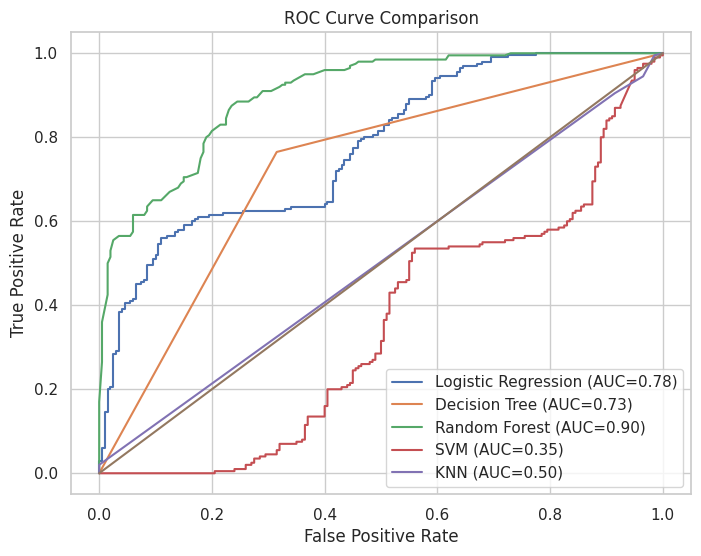


Final Model Comparison:
                 Model  Accuracy
2        Random Forest    0.8200
1        Decision Tree    0.7250
0  Logistic Regression    0.6575
3                  SVM    0.5150
4                  KNN    0.4900


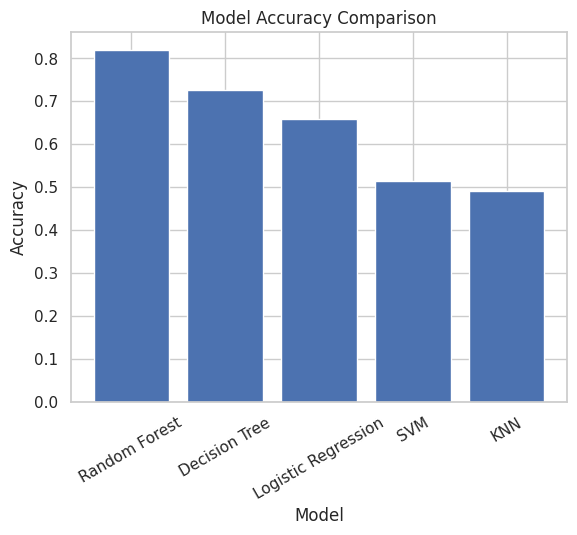

In [15]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


def clean_numeric(series):
    series = series.astype(str).str.replace(r'[^0-9.]', '', regex=True)
    return pd.to_numeric(series, errors='coerce')

for col in ['quantity', 'tradeAmount', 'wishedCount']:
    df[col] = clean_numeric(df[col])

# Fill missing values with median
for col in ['quantity', 'tradeAmount', 'wishedCount']:
    df[col].fillna(df[col].median(), inplace=True)

# ==========================================
# 4. CREATE TARGET (BINARY CLASSIFICATION)
# ==========================================
threshold = df['tradeAmount'].median()
df['target'] = (df['tradeAmount'] > threshold).astype(int)

# ==========================================
# 5. FEATURES & TARGET
# ==========================================
X = df[['title', 'averageStar', 'quantity', 'wishedCount']]
y = df['target']

# ==========================================
# 6. TRAIN-TEST SPLIT (NO DATA LEAKAGE)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# 7. PREPROCESSING (ENCODING + SCALING)
# ==========================================
cat_cols = ['title']
num_cols = ['averageStar', 'quantity', 'wishedCount']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

# ==========================================
# 8. DEFINE MODELS
# ==========================================
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}

results = {}

# ==========================================
# 9. TRAIN + EVALUATE MODELS
# ==========================================
plt.figure(figsize=(8,6))

for name, model in models.items():
    
    # Create pipeline
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train ONLY on training data
    pipe.fit(X_train, y_train)
    
    # Predictions
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results[name] = acc
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print("ROC-AUC:", roc_auc)
    print(classification_report(y_test, y_pred))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

# ==========================================
# 10. PLOT ROC CURVE
# ==========================================
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ==========================================
# 11. MODEL ACCURACY COMPARISON
# ==========================================
results_df = pd.DataFrame(results.items(), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

print("\nFinal Model Comparison:")
print(results_df)

# Bar plot
plt.figure()
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

## Thank you...pls upvote!!!!!